In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [ ]:
df = pd.read_csv("global_green_energy_pulse_20260112.csv")

print("Đọc dữ liệu thành công!")
print("Kích thước dữ liệu:", df.shape)
df.head()

Đọc dữ liệu thành công!
Kích thước dữ liệu: (1920, 7)


,city,time,shortwave_radiation,wind_speed_100m,green_score,latitude,longitude
0,New York,2026-01-05 00:00:00,0.0,22.9,0.763333,40.71,-74.0
1,New York,2026-01-05 01:00:00,0.0,23.4,0.780000,40.71,-74.0
2,New York,2026-01-05 02:00:00,0.0,28.2,0.940000,40.71,-74.0
3,New York,2026-01-05 03:00:00,0.0,30.0,1.000000,40.71,-74.0
4,New York,2026-01-05 04:00:00,0.0,29.7,0.990000,40.71,-74.0


In [ ]:
print("Danh sách biến:")
print(df.columns)

print("\nKiểu dữ liệu:")
print(df.dtypes)

print("\nSố giá trị thiếu:")
print(df.isnull().sum())

Danh sách biến:
Index(['city', 'time', 'shortwave_radiation', 'wind_speed_100m', 'green_score',
       'latitude', 'longitude'],
      dtype='object')

Kiểu dữ liệu:
city                    object
time                    object
shortwave_radiation    float64
wind_speed_100m        float64
green_score            float64
latitude               float64
longitude              float64
dtype: object

Số giá trị thiếu:
city                   0
time                   0
shortwave_radiation    0
wind_speed_100m        0
green_score            0
latitude               0
longitude              0
dtype: int64


In [ ]:
vars_interest = ["shortwave_radiation", "wind_speed_100m", "green_score"]
df[vars_interest].describe()

,shortwave_radiation,wind_speed_100m,green_score
count,1920.000000,1920.000000,1920.000000
mean,151.361615,21.030000,0.852362
std,249.820722,12.921166,0.482430
min,0.000000,0.400000,0.013333
25%,0.000000,10.800000,0.500450
50%,0.000000,19.000000,0.783333
75%,216.200000,28.100000,1.138517
max,1081.000000,71.400000,2.683667


In [ ]:
df["solar_level"] = pd.cut(
    df["shortwave_radiation"],
    bins=5,
    labels=["Rất thấp", "Thấp", "Trung bình", "Cao", "Rất cao"]
)

df["wind_level"] = pd.cut(
    df["wind_speed_100m"],
    bins=5,
    labels=["Rất yếu", "Yếu", "Trung bình", "Mạnh", "Rất mạnh"]
)

In [ ]:
print("TẦN SỐ BỨC XẠ MẶT TRỜI (TRƯỚC)")
print(df["solar_level"].value_counts())
print(df["solar_level"].value_counts(normalize=True))

print("\nTẦN SỐ TỐC ĐỘ GIÓ (TRƯỚC)")
print(df["wind_level"].value_counts())
print(df["wind_level"].value_counts(normalize=True))

TẦN SỐ BỨC XẠ MẶT TRỜI (TRƯỚC)
solar_level
Rất thấp      1440
Thấp           180
Trung bình     160
Cao             96
Rất cao         44
Name: count, dtype: int64
solar_level
Rất thấp      0.750000
Thấp          0.093750
Trung bình    0.083333
Cao           0.050000
Rất cao       0.022917
Name: proportion, dtype: float64

TẦN SỐ TỐC ĐỘ GIÓ (TRƯỚC)
wind_level
Yếu           793
Rất yếu       675
Trung bình    312
Mạnh          114
Rất mạnh       26
Name: count, dtype: int64
wind_level
Yếu           0.413021
Rất yếu       0.351562
Trung bình    0.162500
Mạnh          0.059375
Rất mạnh      0.013542
Name: proportion, dtype: float64


In [ ]:
df_clean = df.dropna(subset=vars_interest)

print("Sau khi loại missing:")
print("Số dòng còn lại:", df_clean.shape[0])

Sau khi loại missing:
Số dòng còn lại: 1920


In [ ]:
df_clean["green_level"] = pd.cut(
    df_clean["green_score"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Thấp", "Trung bình", "Cao"]
)

df_clean["green_level"].value_counts()

,count
green_level,
Cao,643
Trung bình,424
Thấp,223


In [ ]:
print("TẦN SỐ GREEN SCORE (SAU)")
print(df_clean["green_level"].value_counts())
print(df_clean["green_level"].value_counts(normalize=True))

TẦN SỐ GREEN SCORE (SAU)
green_level
Cao           643
Trung bình    424
Thấp          223
Name: count, dtype: int64
green_level
Cao           0.498450
Trung bình    0.328682
Thấp          0.172868
Name: proportion, dtype: float64


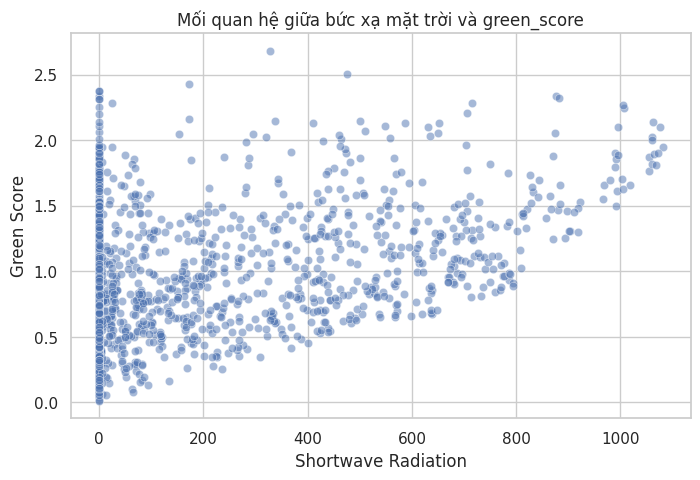

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_clean,
    x="shortwave_radiation",
    y="green_score",
    alpha=0.5
)
plt.title("Mối quan hệ giữa bức xạ mặt trời và green_score")
plt.xlabel("Shortwave Radiation")
plt.ylabel("Green Score")
plt.show()

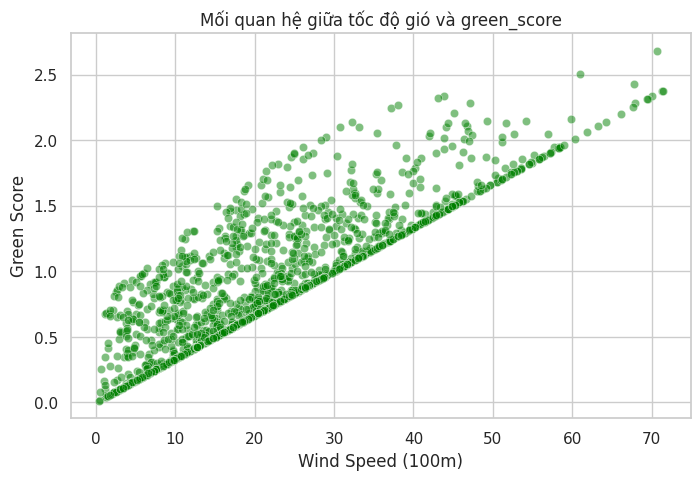

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df_clean,
    x="wind_speed_100m",
    y="green_score",
    alpha=0.5,
    color="green"
)
plt.title("Mối quan hệ giữa tốc độ gió và green_score")
plt.xlabel("Wind Speed (100m)")
plt.ylabel("Green Score")
plt.show()